In [1]:
from pyscarcopula.src.N2.N2Copula import N2Copula
from pyscarcopula.src.N7.N7Copula import N7Copula
from pyscarcopula.src.N8.N8Copula import N8Copula

from pyscarcopula.src.N22.N22Copula import N22Copula
from pyscarcopula.src.N21.N21Copula import N21Copula
from pyscarcopula.src.N20.N20Copula import N20Copula

from pyscarcopula.src.Gumbel.GumbelCopula  import GumbelCopula
from pyscarcopula.src.GenestGhoudi.GenestGhoudiCopula  import GenestGhoudiCopula
from pyscarcopula.src.GumbelBarnett.GumbelBarnettCopula  import GumbelBarnettCopula
from pyscarcopula.src.Frank.FrankCopula  import FrankCopula
from pyscarcopula.src.Joe.JoeCopula  import JoeCopula
from pyscarcopula.src.AliMikhailHaq.AliMikhailHaqCopula  import AliMikhailHaqCopula

from pyscarcopula.metrics.risk_metrics import risk_metrics
from pyscarcopula.aux_functions.funcs import jit_pobs

from scipy.stats import chi2

import pandas as pd
import numpy as np

from tqdm import tqdm 

from matplotlib import pyplot as plt
import matplotlib.ticker as plticker

from numba import jit

from scipy.optimize import minimize
from pyscarcopula.marginal.norm import jit_norm_marginals, jit_norm_rvs
from scipy.optimize import basinhopping, Bounds

from pyscarcopula.sampler.scar_ou.sampler_ou import p_sampler_no_hist_ou, p_sampler_1_step_ou, p_sampler_init_state


Read data

In [2]:
'''Read data and transform returns to pseudo observations'''
returns_data1 = pd.read_csv(r"data/test_returns_data_for_eis.csv", index_col=0) # Data from MOEX for tickers: AFKS, ROSN, SBER, YNDX. 
                                                                                # Data starts from 01.01.2020 with 30-minutes interval  
returns_data2 = pd.read_csv(r"data/dj.csv", sep=';') # Daily data of indexies DowJones и NASDAQ. 
                                                     # Data starts from 01.01.1990

moex_data = pd.read_csv("data/moex_top.csv", index_col=0)
tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK', 'ROSN', 'KMAZ', 'AFKS', 'BSPB', 'MGNT']
#tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK']
moex_returns_pd = np.log(moex_data[tickers] / moex_data[tickers].shift(1))[1:601]
moex_returns = moex_returns_pd.values
pobs_data = jit_pobs(moex_returns)


count_instruments = len(tickers)
copula = GumbelCopula(count_instruments)

Available approximations methods

In [20]:
'''Copula could be approximated by calling method `fit`. 
Available methods:
1. MLE - maximum likelihood estimation (by default)
2. SCAR-M-DS - efficient importance sampling (discrete case) 
3. SCAR-M-OU - efficient importance sampling (continuous case, Ornstein-Uhlenbeck latent process)
4. SCAR-P-LD - natural sampler (continuous case, logistic distribution for latent process)
Example of approximation for Gumbel copula.. The path which minimizer goes through is printed. 
Result of calculations - fun - value of log likelihood (for SCAR methods -- average on number of trajectories `n_tr`);
x - set of regression parameters omega.

First run could lasts longer due to optimizations of numba python library (functions runs after compilation. Second runs starts immediately).
'''
gum_cop = GumbelCopula(2)
gum_cop.fit(returns_data2.values, latent_process_tr = 200, m_iters = 5, method = 'SCAR-M-DS', seed = 10, to_pobs=True, print_path = True)

[0.05 0.95 0.05] -719.3403425373476
[0.05000001 0.95       0.05      ] -719.3402596744022
[0.05       0.95000001 0.05      ] -719.3402665599996
[0.05       0.95       0.05000001] -719.3403352730154
[-1.000e+01 -3.999e+00  1.000e-03] params is out of bounds 10000
[-9.99999999e+00 -3.99900000e+00  1.00000000e-03] params is out of bounds 10000
[-1.00000000e+01 -3.99899999e+00  1.00000000e-03] params is out of bounds 10000
[-1.00000e+01 -3.99900e+00  1.00001e-03] params is out of bounds 10000
[-2.79548152 -0.45122269  0.03612651] 2159.734473898105
[-2.79548151 -0.45122269  0.03612651] 2159.7344351463535
[-2.79548152 -0.45122268  0.03612651] 2159.7345500853794
[-2.79548152 -0.45122269  0.03612652] 2159.7344671847472
[-0.76584777  0.54824571  0.04602223] 974.8463302440031
[-0.76584776  0.54824571  0.04602223] 974.846233095126
[-0.76584777  0.54824572  0.04602223] 974.8464934004088
[-0.76584777  0.54824571  0.04602224] 974.8463244539402
[-0.16437795  0.84443219  0.04895477] -676.2852272969673

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 841.906925380205
        x: [ 4.210e-04  9.994e-01  1.172e-02]
      nit: 29
      jac: [-7.009e+02 -5.365e+02 -1.426e+01]
     nfev: 440
     njev: 110
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
     name: Gumbel copula
   method: SCAR-M-DS

In [22]:
gum_cop.fit(returns_data2.values, latent_process_tr = 3000, m_iters = 7, method = 'SCAR-M-OU', seed = 10)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 878.2186909510652
        x: [ 3.712e+00  2.830e+00  3.451e-01]
      nit: 11
      jac: [ 4.025e+00 -9.779e+00 -1.628e+00]
     nfev: 88
     njev: 22
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
     name: Gumbel copula
   method: SCAR-M-OU

In [23]:
'''MLE'''
gum_cop.fit(returns_data2.values, method = 'MLE')

       message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
       success: True
        status: 0
           fun: 739.7015958107223
             x: [ 8.700e-01]
           nit: 4
           jac: [-1.542e-02]
          nfev: 12
          njev: 6
      hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>
          name: Gumbel copula
        method: MLE
 x_transformed: [ 1.757e+00]

In [15]:
'''risk_metrics'''
gamma = [0.9, 0.95, 0.97, 0.99, 0.999]
window_len = 250
latent_process_tr = 200
MC_iterations = [int(10**6)]
#method = 'SCAR-M-OU'
method = 'MLE'
cpus = 6
result = risk_metrics(copula, moex_returns, window_len, 
                                                gamma, MC_iterations,
                                                marginals_params_method = 'norm',
                                                latent_process_type = method,
                                                latent_process_tr = latent_process_tr,
                                                optimize_portfolio = False, 
                                                portfolio_type = 'I',
                                                portfolio_weight = None,
                                                cpu_processes=cpus)

calc copula params


100%|██████████| 351/351 [00:13<00:00, 26.29it/s]


calc marginals_params
gamma = 0.9, MC_iterations = 1000000
calc portfolio


100%|██████████| 351/351 [04:01<00:00,  1.46it/s]

gamma = 0.95, MC_iterations = 1000000
calc portfolio


...


100%|██████████| 351/351 [03:51<00:00,  1.52it/s]


gamma = 0.99, MC_iterations = 1000000
calc portfolio


100%|██████████| 351/351 [04:04<00:00,  1.44it/s]

gamma = 0.999, MC_iterations = 1000000
calc portfolio



100%|██████████| 351/351 [04:00<00:00,  1.46it/s]


In [16]:
pd_var_90 = pd.Series(data = -result[0.90][1000000]['var'], index=moex_returns_pd.index).shift(1)
pd_var_95 = pd.Series(data = -result[0.95][1000000]['var'], index=moex_returns_pd.index).shift(1)
pd_var_97 = pd.Series(data = -result[0.97][1000000]['var'], index=moex_returns_pd.index).shift(1)
pd_var_99 = pd.Series(data = -result[0.99][1000000]['var'], index=moex_returns_pd.index).shift(1)
pd_var_999 = pd.Series(data = -result[0.999][1000000]['var'], index=moex_returns_pd.index).shift(1)
weight = result[0.9][1000000]['weight']

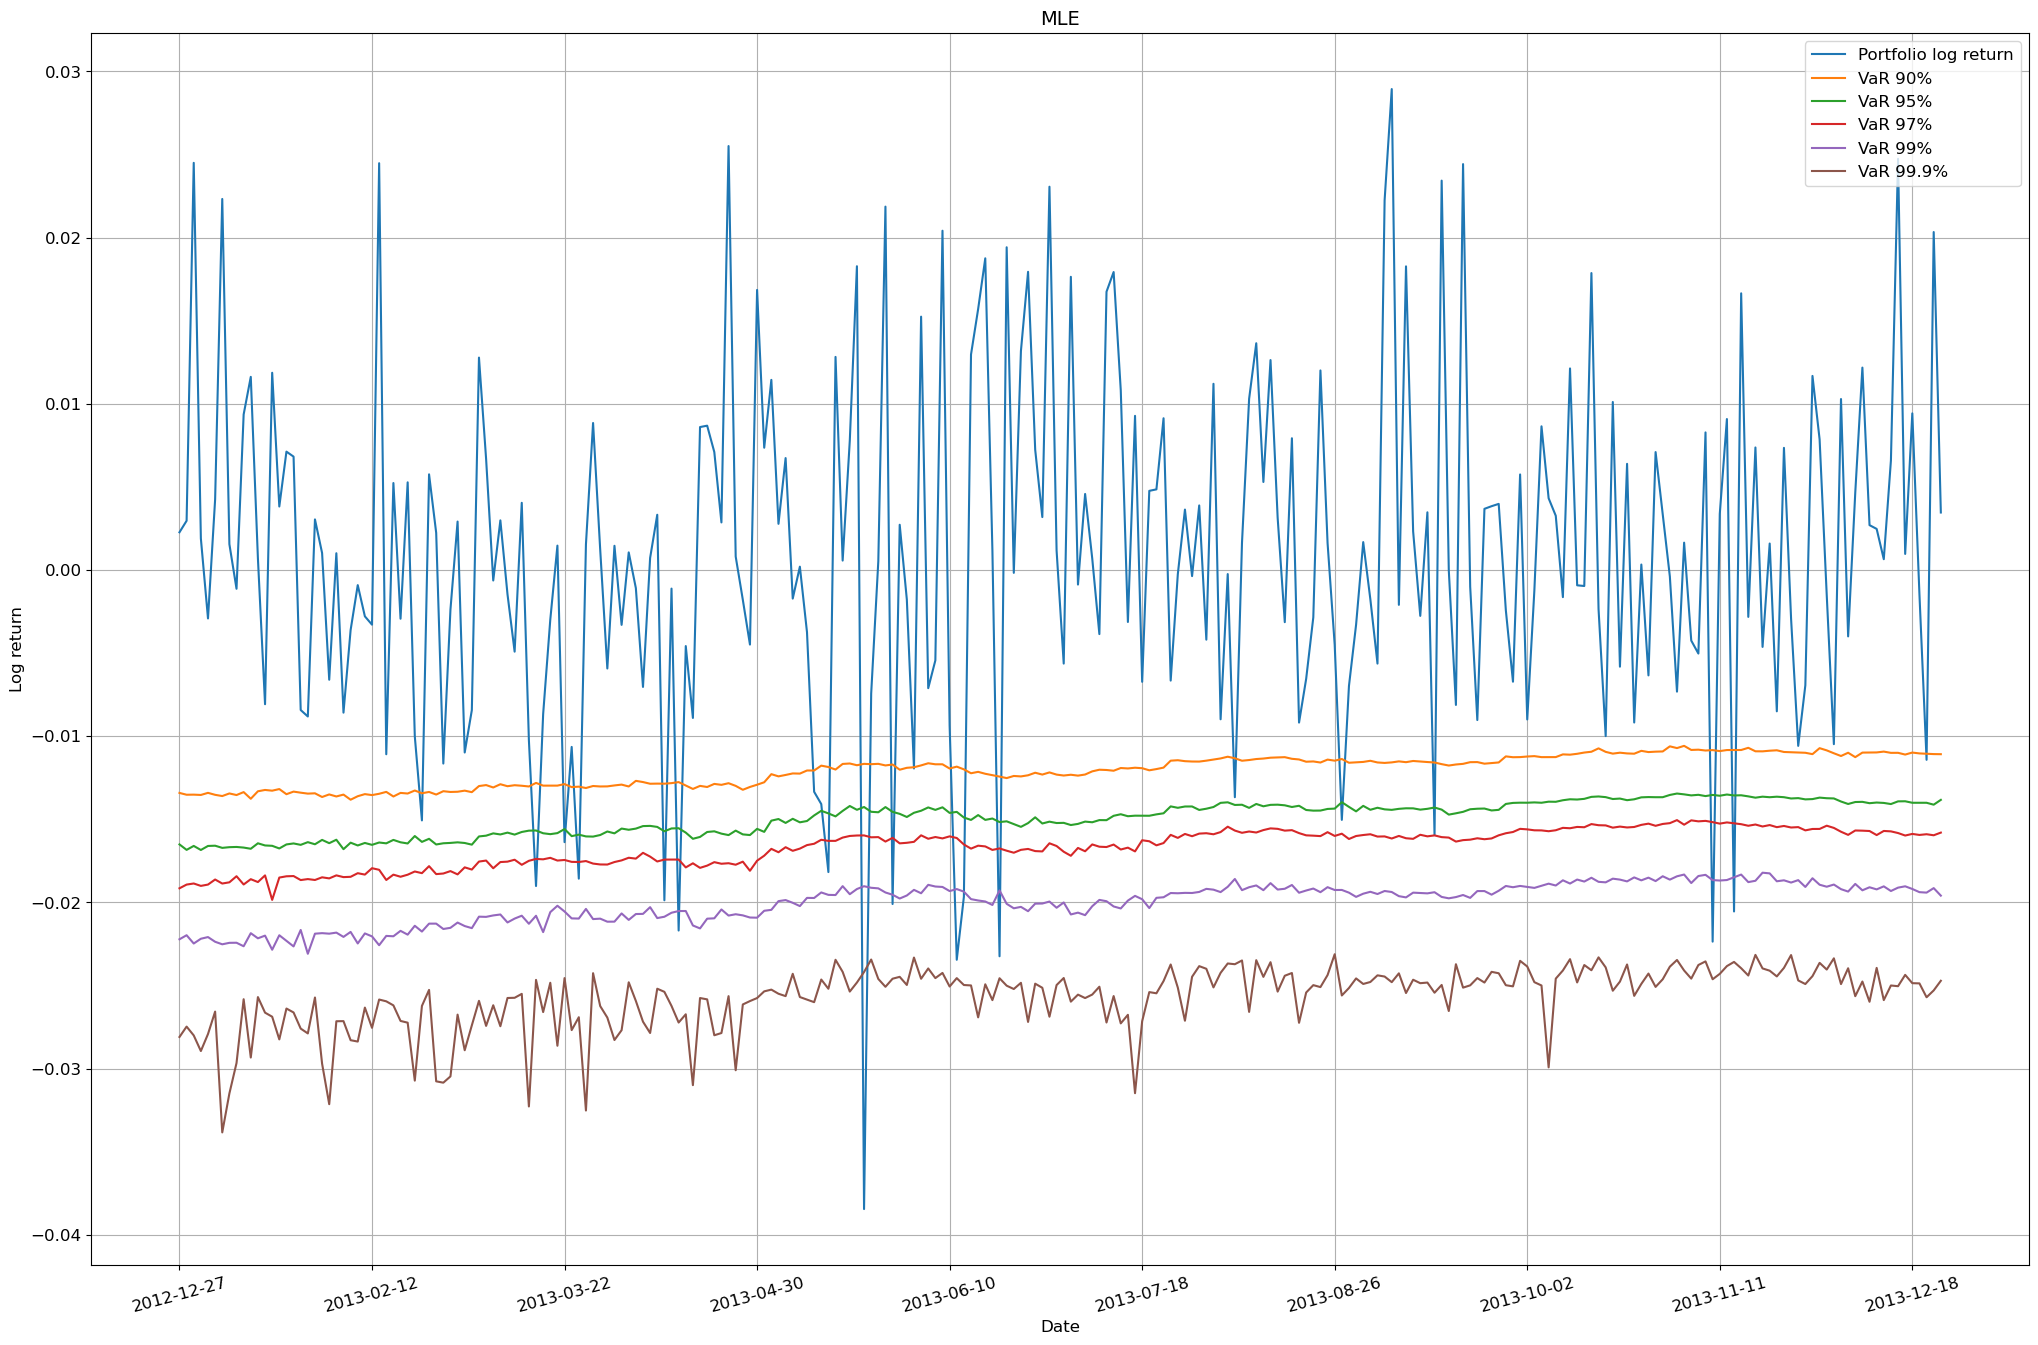

In [18]:
n = 1
m = 1
fig,ax = plt.subplots(n,m,figsize=(25,16))
i1 = 252
i2 = 500
loc = plticker.MultipleLocator(base=27.0)

#ax.plot(((np.exp(moex_returns_pd) - 1) * pd_weight_data).sum(axis=1)[i1:i2], label = 'Portfolio log return')
ax.plot(((np.exp(moex_returns_pd) - 1) * weight).sum(axis=1)[i1:i2], label = 'Portfolio log return')

ax.plot(pd_var_90[i1:i2], label = 'VaR 90%')
ax.plot(pd_var_95[i1:i2], label = 'VaR 95%')
ax.plot(pd_var_97[i1:i2], label = 'VaR 97%')
ax.plot(pd_var_99[i1:i2], label = 'VaR 99%')
ax.plot(pd_var_999[i1:i2], label = 'VaR 99.9%')

#ax.plot(pd_cvar[i1:i2], label = 'CVaR 95%')
ax.set_title(f'{method}', fontsize = 14)

ax.xaxis.set_major_locator(loc)
ax.set_xlabel('Date', fontsize = 12, loc = 'center')
ax.set_ylabel('Log return', fontsize = 12, loc = 'center')
ax.tick_params(axis='x', labelrotation = 15, labelsize = 12)
ax.tick_params(axis='y', labelsize = 12)
ax.grid(True)
ax.legend(fontsize=12, loc = 'upper right')
